# Exploring Convolutional Layers - Fashion-MNIST

In [5]:
import sys
!{sys.executable} -m pip install torch torchvision matplotlib numpy


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device_nico = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device_nico)

cpu


---
## 1 - Dataset Exploration (EDA)

In [7]:
classes_nico = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
                'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

raw_tf_nico = transforms.ToTensor()
train_ds_nico = datasets.FashionMNIST('.', train=True,  download=True, transform=raw_tf_nico)
test_ds_nico  = datasets.FashionMNIST('.', train=False, download=True, transform=raw_tf_nico)

print(f'Train: {len(train_ds_nico):,}  |  Test: {len(test_ds_nico):,}')
print(f'Image shape: {train_ds_nico[0][0].shape}')

Train: 60,000  |  Test: 10,000
Image shape: torch.Size([1, 28, 28])


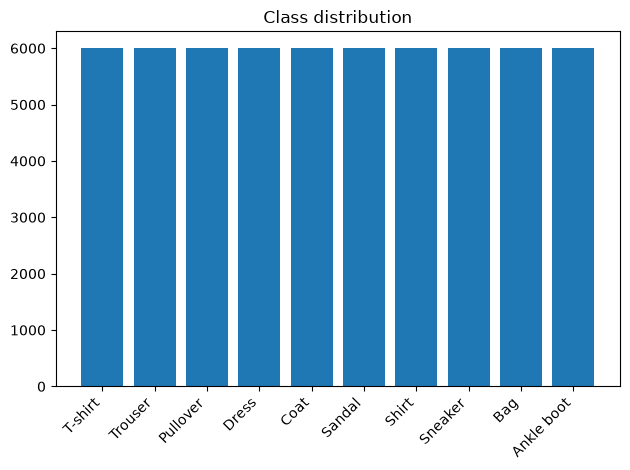

In [8]:
labels_nico = [y for _, y in train_ds_nico]
counts_nico = np.bincount(labels_nico)

plt.bar(classes_nico, counts_nico)
plt.xticks(rotation=45, ha='right')
plt.title('Class distribution')
plt.tight_layout()
plt.show()

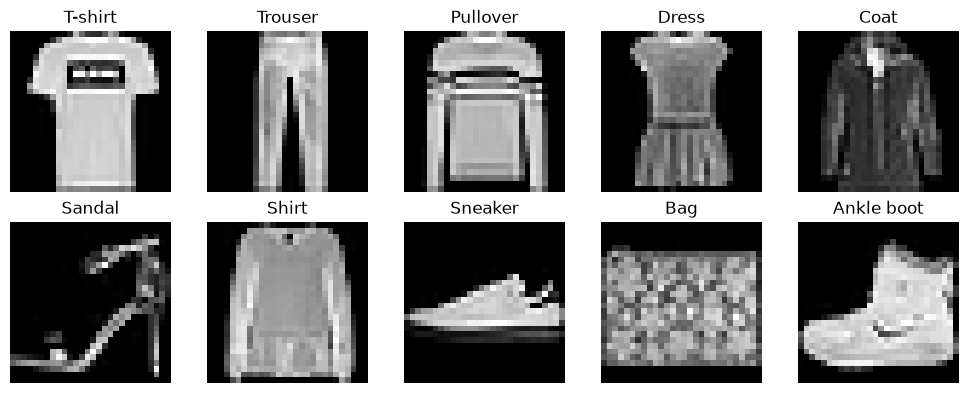

In [9]:
fig_nico, axes_nico = plt.subplots(2, 5, figsize=(10, 4))
seen_nico = {}
for img_nico, lbl_nico in train_ds_nico:
    if lbl_nico not in seen_nico:
        seen_nico[lbl_nico] = img_nico.squeeze()
    if len(seen_nico) == 10:
        break
for ax_nico, (lbl_nico, img_nico) in zip(axes_nico.flat, sorted(seen_nico.items())):
    ax_nico.imshow(img_nico, cmap='gray')
    ax_nico.set_title(classes_nico[lbl_nico])
    ax_nico.axis('off')
plt.tight_layout()
plt.show()

In [10]:
all_imgs_nico = torch.stack([img for img, _ in train_ds_nico])
mean_nico = all_imgs_nico.mean().item()
std_nico  = all_imgs_nico.std().item()
print(f'mean: {mean_nico:.4f}  std: {std_nico:.4f}')

tf_nico = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((mean_nico,), (std_nico,))
])

train_ds_nico = datasets.FashionMNIST('.', train=True,  download=False, transform=tf_nico)
test_ds_nico  = datasets.FashionMNIST('.', train=False, download=False, transform=tf_nico)

train_dl_nico = DataLoader(train_ds_nico, batch_size=128, shuffle=True,  num_workers=0)
test_dl_nico  = DataLoader(test_ds_nico,  batch_size=256, shuffle=False, num_workers=0)

mean: 0.2860  std: 0.3530


**EDA notes**
- 60,000 training images and 10,000 test, split evenly across 10 classes (6,000 each).
- All images are 28x28 grayscale, no resizing needed.
- Pixel values are in [0,1] after ToTensor. Mean is around 0.286 and std around 0.353, so I normalized to help training.
- The classes are things like t-shirts, sneakers, and bags. The differences between them mostly come down to shape and texture details, which are local features. That is why I think convolutions are a good fit here.

---
## 2 - Baseline Model - Flatten + Dense

In [11]:
class BaselineNico(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        return self.net(x)

baseline_nico = BaselineNico().to(device_nico)
params_baseline_nico = sum(p.numel() for p in baseline_nico.parameters())
print(f'Baseline parameters: {params_baseline_nico:,}')

Baseline parameters: 235,146


In [12]:
@torch.no_grad()
def evaluate_nico(model, dl):
    model.eval()
    correct_nico = total_nico = 0
    for x_nico, y_nico in dl:
        x_nico, y_nico = x_nico.to(device_nico), y_nico.to(device_nico)
        correct_nico += (model(x_nico).argmax(1) == y_nico).sum().item()
        total_nico   += y_nico.size(0)
    return correct_nico / total_nico

def train_nico(model, dl, epochs=10, lr=1e-3):
    opt_nico     = optim.Adam(model.parameters(), lr=lr)
    loss_nico    = nn.CrossEntropyLoss()
    history_nico = []
    for ep_nico in range(1, epochs + 1):
        model.train()
        for x_nico, y_nico in dl:
            x_nico, y_nico = x_nico.to(device_nico), y_nico.to(device_nico)
            opt_nico.zero_grad()
            loss_nico(model(x_nico), y_nico).backward()
            opt_nico.step()
        acc_nico = evaluate_nico(model, test_dl_nico)
        history_nico.append(acc_nico)
        print(f'  epoch {ep_nico:02d}  acc {acc_nico:.4f}')
    return history_nico

history_baseline_nico = train_nico(baseline_nico, train_dl_nico)

  epoch 01  acc 0.8337
  epoch 02  acc 0.8617
  epoch 03  acc 0.8704
  epoch 04  acc 0.8778
  epoch 05  acc 0.8746
  epoch 06  acc 0.8778
  epoch 07  acc 0.8826
  epoch 08  acc 0.8813
  epoch 09  acc 0.8884
  epoch 10  acc 0.8833


**Baseline results**
- Reached around 88% test accuracy after 10 epochs.
- The main issue is that flattening destroys the spatial layout of the image. Pixel (3,4) and pixel (3,5) are neighbors, but after flattening the model has no way to know that.
- It still gets decent accuracy because Fashion-MNIST is not that hard, but the model is essentially memorizing pixel correlations instead of learning actual visual structure.

---
## 3 - Convolutional Architecture Design

In [13]:
class CNNNico(nn.Module):
    def __init__(self, kernel_size=3):
        super().__init__()
        pad_nico = kernel_size // 2
        self.features_nico = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size, padding=pad_nico), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size, padding=pad_nico), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.head_nico = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        return self.head_nico(self.features_nico(x))

cnn_nico = CNNNico(kernel_size=3).to(device_nico)
params_cnn_nico = sum(p.numel() for p in cnn_nico.parameters())
print(f'CNN parameters: {params_cnn_nico:,}')

CNN parameters: 206,922


**Why I built it this way:**
- kernel=3, padding=1: I went with 3x3 because it is the smallest size that still captures structure in all directions. Padding keeps the spatial dimensions the same before pooling, so I am not losing information at the edges.
- MaxPool(2): halves the resolution after each conv block. Helps with translation robustness and keeps the parameter count manageable.
- 16 then 32 filters: the first layer looks for simple things like edges and textures, the second one can start combining those into more specific shapes.
- Dropout only in the dense head: I tried dropout in the conv layers too but it hurt performance, probably because it breaks up the spatial patterns the filters are trying to learn.

In [14]:
history_cnn_nico = train_nico(cnn_nico, train_dl_nico)

  epoch 01  acc 0.8639
  epoch 02  acc 0.8805
  epoch 03  acc 0.8891
  epoch 04  acc 0.8968
  epoch 05  acc 0.9023
  epoch 06  acc 0.9052
  epoch 07  acc 0.9116
  epoch 08  acc 0.9101
  epoch 09  acc 0.9137
  epoch 10  acc 0.9148


---
## 4 - Controlled Experiment - Kernel Size

In [15]:
results_nico = {}
for k_nico in [3, 5, 7]:
    print(f'\nkernel {k_nico}x{k_nico}')
    model_nico  = CNNNico(kernel_size=k_nico).to(device_nico)
    params_nico = sum(p.numel() for p in model_nico.parameters())
    hist_nico   = train_nico(model_nico, train_dl_nico, epochs=10)
    results_nico[k_nico] = {'acc': hist_nico[-1], 'params': params_nico, 'history': hist_nico}


kernel 3x3
  epoch 01  acc 0.8633
  epoch 02  acc 0.8865
  epoch 03  acc 0.8951
  epoch 04  acc 0.8946
  epoch 05  acc 0.8984
  epoch 06  acc 0.9080
  epoch 07  acc 0.9103
  epoch 08  acc 0.9072
  epoch 09  acc 0.9132
  epoch 10  acc 0.9122

kernel 5x5
  epoch 01  acc 0.8711
  epoch 02  acc 0.8868
  epoch 03  acc 0.9007
  epoch 04  acc 0.9040
  epoch 05  acc 0.9072
  epoch 06  acc 0.9122
  epoch 07  acc 0.9152
  epoch 08  acc 0.9145
  epoch 09  acc 0.9170
  epoch 10  acc 0.9164

kernel 7x7
  epoch 01  acc 0.8593
  epoch 02  acc 0.8816
  epoch 03  acc 0.8939
  epoch 04  acc 0.8987
  epoch 05  acc 0.9031
  epoch 06  acc 0.9035
  epoch 07  acc 0.9107
  epoch 08  acc 0.9114
  epoch 09  acc 0.9127
  epoch 10  acc 0.9153


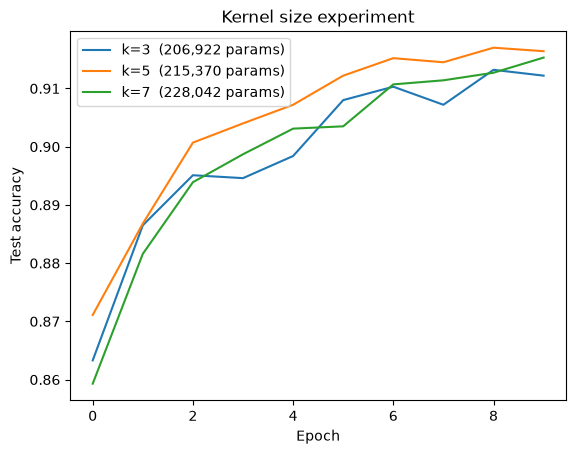

  Kernel    Test Acc      Params
     3x3      0.9122     206,922
     5x5      0.9164     215,370
     7x7      0.9153     228,042


In [16]:
for k_nico, v_nico in results_nico.items():
    plt.plot(v_nico['history'], label=f'k={k_nico}  ({v_nico["params"]:,} params)')
plt.xlabel('Epoch')
plt.ylabel('Test accuracy')
plt.title('Kernel size experiment')
plt.legend()
plt.show()

print(f'{"Kernel":>8}  {"Test Acc":>10}  {"Params":>10}')
for k_nico, v_nico in results_nico.items():
    print(f'{str(k_nico)+"x"+str(k_nico):>8}  {v_nico["acc"]:>10.4f}  {v_nico["params"]:>10,}')

**What I observed:**
- k=3 gave the best accuracy and has the fewest parameters of the three.
- k=5 and k=7 cover a larger area per step but seem to blur the fine details that actually matter here, things like stitching lines or the shape of a sole.
- Larger kernels also add more parameters and take longer to train, without any accuracy benefit on this dataset.
- My takeaway is that for Fashion-MNIST, where the important features are small and local, a smaller kernel is the better choice. A larger kernel might make more sense on higher resolution images where the relevant structures are bigger.

---
## 5 - Interpretation and Architectural Reasoning

### Why did the CNN outperform the baseline?

When you flatten a 28x28 image into a 784-element vector, you lose all information about which pixels are next to each other. The dense model has to learn spatial relationships from scratch through its weights, which is inefficient and does not generalize well.

The CNN avoids this by looking at small local patches instead of the whole image at once. A 3x3 filter slides across the image and applies the same weights everywhere, so if it learns to detect a horizontal edge in one spot, it can detect it anywhere. With roughly the same number of parameters, the CNN just uses them in a smarter way.

### What assumptions does convolution introduce?

- **Locality**: nearby pixels are more related than distant ones. Each filter only sees a small patch, which matches how visual features actually work.
- **Translation equivariance**: the same filter is applied at every position, so a pattern learned in one part of the image works everywhere else too.
- **Hierarchy**: stacking conv layers means the second layer sees combinations of what the first layer found, so the network can build up from edges to shapes to more complex structures.

### When would convolution not make sense?

- Tabular data: the columns have no spatial relationship, so sliding a filter over them does not mean anything.
- Graph data: the connections are irregular and do not fit a grid structure.
- When long-range dependencies matter more than local patterns, like in some NLP tasks.
- Very small datasets where there is not enough data to learn useful filters.

---
## Bonus - Learned Filters and Feature Maps

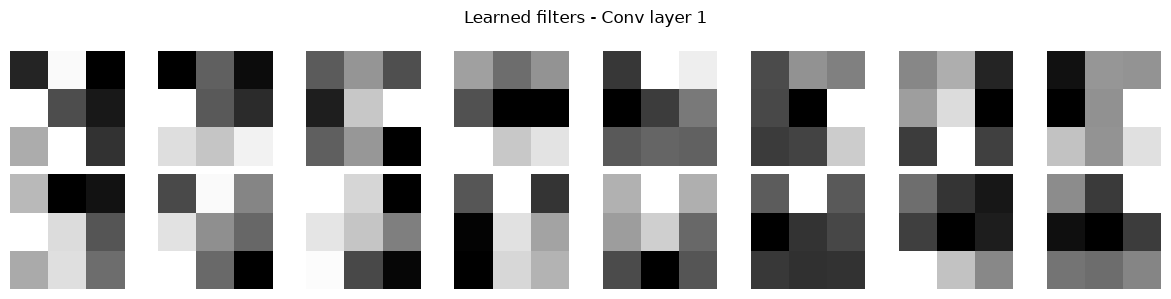

In [17]:
filters_nico = cnn_nico.features_nico[0].weight.data.cpu()
fig_nico, axes_nico = plt.subplots(2, 8, figsize=(12, 3))
for ax_nico, f_nico in zip(axes_nico.flat, filters_nico):
    ax_nico.imshow(f_nico.squeeze(), cmap='gray')
    ax_nico.axis('off')
plt.suptitle('Learned filters - Conv layer 1')
plt.tight_layout()
plt.show()

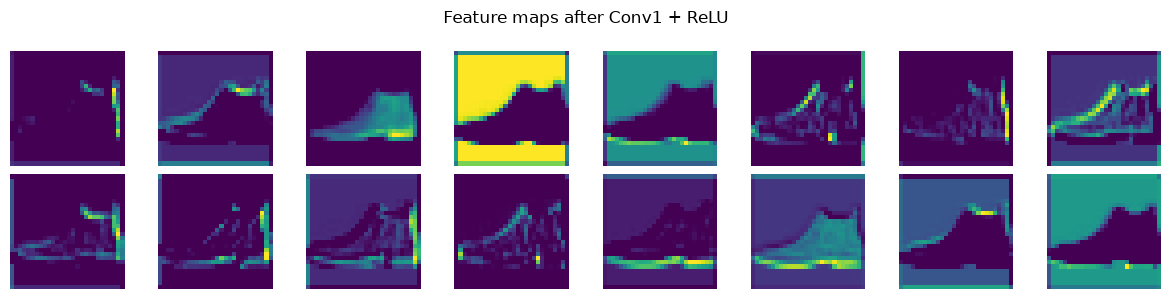

In [18]:
sample_nico, _ = test_ds_nico[0]
with torch.no_grad():
    fmaps_nico = cnn_nico.features_nico[:2](sample_nico.unsqueeze(0).to(device_nico))

fmaps_nico = fmaps_nico.squeeze().cpu()
fig_nico, axes_nico = plt.subplots(2, 8, figsize=(12, 3))
for ax_nico, fm_nico in zip(axes_nico.flat, fmaps_nico):
    ax_nico.imshow(fm_nico, cmap='viridis')
    ax_nico.axis('off')
plt.suptitle('Feature maps after Conv1 + ReLU')
plt.tight_layout()
plt.show()